In [ ]:
# 0: 
'''
My dataset shows 10851 collisions of two protons
and the resulting muon pairs.
All data was collected at the LHC at CERN
I wonder what kind of relationship exists between the muons'
invariant mass resolution (imr) and transverse momentum (pt)
More specifically, I want to look at how the mass resolution changes for 
low pt and high pt muons.

*** Invariant mass resolution = how accurately a particle detector can
determine the invariant mass of a particle by measuring their decay
products ***
'''

In [13]:
# 1:
import pandas as pd
zmumu = pd.read_csv('Zmumu_Run2011A_masses.csv')
print(zmumu.shape)
print(zmumu.head())

(10851, 21)
      Run     Event Type1        E1       px1      py1       pz1      pt1  \
0  165617  74969122     G   59.9226 -46.15160  29.4115  -24.4070  54.7055   
1  165617  75138253     G   97.1011 -23.61440   6.6660  -93.9497  24.5872   
2  165617  75887636     G  152.9720   7.46565 -30.7098 -149.6710  31.7386   
3  165617  75833588     G  181.8770  44.14270 -14.9498  175.8040  46.7085   
4  165617  75779415     G   50.2440  37.80720 -12.2044  -30.7590  39.7394   

       eta1      phi1  ...  Type2        E2       px2       py2        pz2  \
0 -0.432396  2.574210  ...      G   52.4465  30.10970 -16.39890  -39.68760   
1 -2.052200  2.866570  ...      G   30.5992 -11.61340 -25.98480   11.23470   
2 -2.259450 -1.332290  ...      G   33.5835  -9.28778  28.74570  -14.67190   
3  2.037940 -0.326565  ...      G  170.0210 -34.63010  12.32480  166.00000   
4 -0.712338 -0.312266  ...      G   49.2396 -47.60640   8.23376   -9.50613   

       pt2      eta2      phi2  Q2        M  
0  34.2464

In [31]:
# 2: 
import numpy as np
# count how many events are low pt vs high pt
pt_values = zmumu["pt1"].to_numpy() # converting datafunction to numpy array
median_pt = np.median(pt_values) # finding the middle value so I can classify "high" and "low"
low_pt = 0 
high_pt = 0
for pt in pt_values:
    if pt < median_pt: # counting low pt values
        low_pt += 1
    else: # counting high pt values
        high_pt += 1

In [30]:
# 3:
# splitting the pt events into low and high and creating a list containing the invariant masses for each classification
low_pt_mass = [] # creating empty lists
high_pt_mass = []
for i in range(len(zmumu)): # itterating over every row in my dataset
    if zmumu["pt1"][i] < median_pt:
        low_pt_mass.append(zmumu["M"][i]) # add to low pt list
    else:
        high_pt_mass.append(zmumu["M"][i]) # add to high pt list

In [32]:
# 4:
# creating a function that computes the mass resolution of a set of invariant mass values
def mass_res(masses):
    '''
Computes mass resolution of a set of invariant mass values
Parameters: masses: invariant mass values
Returns: float: std of mass distribution
    '''
    return np.std(masses)
# calling twice to compute low and high resolutions from the low and high pt values I classified earlier
print(mass_res.__doc__)
low_res = mass_res(low_pt_mass)
print("Low pt mass resolution", low_res)
high_res = mass_res(high_pt_mass)
print("High pt mass resolution", high_res)
# compute low and high mass resolutions from the low and high pts classified erlier


Computes mass resolution of a set of invariant mass values
Parameters: masses: invariant mass values
Returns: float: std of mass distribution
    
Low pt mass resolution 9.515181745425592
High pt mass resolution 6.125416394944898


In [17]:
# 5:
mass_array = zmumu["M"].to_numpy() # takes "M" column and converts to numpy array
pt_array = zmumu["pt1"].to_numpy() # same as above with "pt1"
print("Mean mass:", np.mean(mass_array))
high_pt_mask = pt_array > median_pt # creates boolean mask for high pt values with events that are high pt = True
high_pt_mass_array = mass_array[high_pt_mask] # gives only the mass values where the mask is True
print("High pt events:", len(high_pt_mass_array)) # returns number of high pt events
print("Mass of first event:", mass_array[0])

Mean mass: 88.40254681596166
High pt events: 5425
Mass of first event: 89.9557


In [33]:
# 6: 
resolutions = {} # creating an empty dictionary
resolutions["low_pt"] = low_res # stores the results in the dictionary
resolutions["high_pt"] = high_res
for key in resolutions: # for every key in the resolutions dictionary, print the key then the resolution associated with the key
    print(key, ":", resolutions[key])
if resolutions["low_pt"] > resolutions["high_pt"]:
    print("Low pt has worse resolution")
else:
    print("High pt has worse resolution")

low_pt : 9.515181745425592
high_pt : 6.125416394944898
Low pt has worse resolution


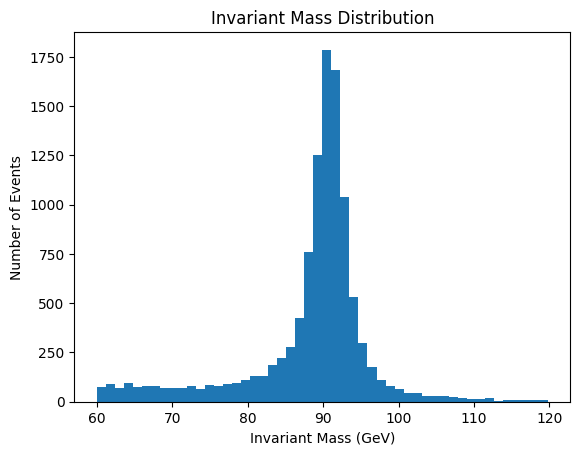

In [19]:
# 7.1
import matplotlib.pyplot as plt
plt.hist(mass_array, bins=50) # plotting a histogram of the mass numpy array
plt.xlabel("Invariant Mass (GeV)")
plt.ylabel("Number of Events")
plt.title("Invariant Mass Distribution")
plt.show()
# peak areoung 91 GeV

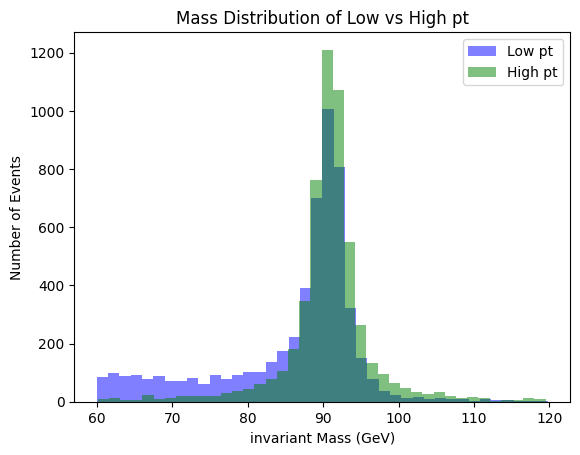

In [20]:
#7.2
plt.hist(low_pt_mass, bins=40, alpha=0.5, label="Low pt", color="Blue") # plotting low and high mass overlapping
plt.hist(high_pt_mass, bins=40, alpha=0.5, label="High pt", color="Green")
plt.xlabel("invariant Mass (GeV)")
plt.ylabel("Number of Events")
plt.title("Mass Distribution of Low vs High pt")
plt.legend()
plt.show()

In [ ]:
# 8:
from sklearn.linear_model import LinearRegression
x = pt_array.reshape(-1, 1) # sk learn expects a 2D array, and my current pt array is 1D
y = mass_array
model = LinearRegression()
model.fit(x, y)
r_squared = model.score(x, y)
print("R^2:", r_squared)

R^2: 0.10437050695814853
0.18900369041670104
81.13705455189049


In [ ]:
'''
An R^2 value of 0.1 means there is some linear relationship between pt and 
invariant mass, but for true Z boson decays, they should theoretically be
independent. This finding could be because of a few things:
the detector isnt perfect, and there could be background contaminiation, I also 
only looked at pt1, if i looked at pt2 as well, my findings might be closer
to the expected value (very low R^2)
'''